In [263]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [264]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\Telegram Desktop\healthcare-dataset-stroke-data.csv")
print(df.shape)
df.head()

(5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


##Data Cleaning

In [266]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [267]:
df.isna().mean() *100

id                   0.000000
gender               0.000000
age                  0.000000
hypertension         0.000000
heart_disease        0.000000
ever_married         0.000000
work_type            0.000000
Residence_type       0.000000
avg_glucose_level    0.000000
bmi                  3.933464
smoking_status       0.000000
stroke               0.000000
dtype: float64

In [268]:
df.duplicated().sum()

0

<AxesSubplot:ylabel='bmi'>

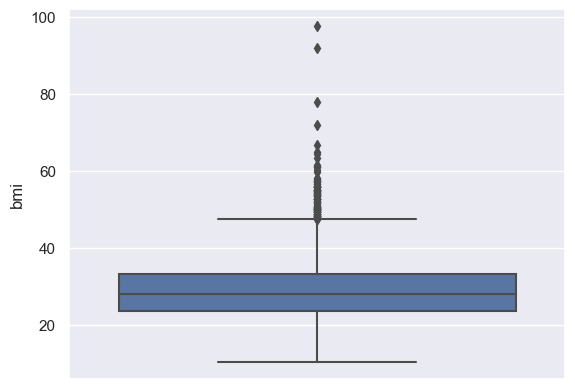

In [269]:
sns.boxplot(y = df['bmi'])

Since the bmi column has outliers,I would employ median imputation, I'll explore age category and get the median for each category to impute the null values

let's group our age into category and check

In [270]:
def agegroup(age):
    if age >= 0 and age < 18:
        return 'Teens'
    elif age >= 18 and age < 40:
        return 'Young adult'
    elif age >= 40 and age < 55:
        return 'Early midlife'
    elif age >= 55 and age < 65:
        return 'Late midlife'
    elif age >= 65 and age < 75:
        return 'Early Elderly'
    else:
        return 'Old age'

In [271]:
df['agegroup'] = df['age'].apply(agegroup)
print(df.shape)
df.head()

(5110, 13)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Late midlife
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


In [272]:
df[df['bmi'].isna()].head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,Late midlife
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1,Late midlife
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1,Old age
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1,Late midlife
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1,Late midlife
29,69160,Male,59.0,0,0,Yes,Private,Rural,211.78,NaN,formerly smoked,1,Late midlife
43,1845,Female,63.0,0,0,Yes,Private,Urban,90.90,NaN,formerly smoked,1,Late midlife
46,37937,Female,75.0,0,1,No,Self-employed,Urban,109.78,NaN,Unknown,1,Old age
50,18587,Female,76.0,0,0,No,Private,Urban,89.96,NaN,Unknown,1,Old age
51,15102,Male,78.0,1,0,Yes,Private,Urban,75.32,NaN,formerly smoked,1,Old age


In [273]:
bmi_median =df.groupby('agegroup')['bmi'].median().reset_index()
bmi_median


,agegroup,bmi
0,Early Elderly,29.55
1,Early midlife,30.30
2,Late midlife,30.40
3,Old age,28.00
4,Teens,19.90
5,Young adult,27.70


In [274]:
df['bmi'] = df['bmi'].fillna(df.groupby('agegroup')['bmi'].transform('median')) #filled missing value based on the median for each age group

In [275]:
df.iloc[81]

id                           26015
gender                      Female
age                           66.0
hypertension                     0
heart_disease                    0
ever_married                   Yes
work_type            Self-employed
Residence_type               Urban
avg_glucose_level           101.45
bmi                          29.55
smoking_status             Unknown
stroke                           1
agegroup             Early Elderly
Name: 81, dtype: object

In [276]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
 12  agegroup           5110 non-null   object 
dtypes: float64(3), int64(4), object(6)
memory usage: 519.1+ KB


In [277]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
agegroup             0
dtype: int64

In [278]:
df['age']=df['age'].astype(int)

In [279]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


#Explore other columns

In [280]:
df['ever_married'].value_counts()

Yes    3353
No     1757
Name: ever_married, dtype: int64

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int32  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
 12  agegroup           5110 non-null   object 
dtypes: float64(2), int32(1), int64(4), object(6)
memory usage: 499.1+ KB


In [282]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


In [283]:
df['gender'].value_counts()

Female    2994
Male      2115
Other        1
Name: gender, dtype: int64

In [284]:
df[df['gender'].str.contains('Other')]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
3116,56156,Other,26,0,0,No,Private,Rural,143.33,22.4,formerly smoked,0,Young adult


The gender colum contains two dominant categories("male and female") and one observation with"other". This particular category represent only one record,therefore it has no meaningful statistical importance for our model

In [285]:
df = df[df['gender'] != 'Other'].reset_index(drop=True)


In [286]:
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5104,18234,Female,80,1,0,Yes,Private,Urban,83.75,28.0,never smoked,0,Old age
5105,44873,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Old age
5106,19723,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Young adult
5107,37544,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Early midlife


In [287]:
df['gender'].value_counts()

Female    2994
Male      2115
Name: gender, dtype: int64

In [288]:
df.shape

(5109, 13)

In [289]:
df['hypertension'].value_counts()

0    4611
1     498
Name: hypertension, dtype: int64

In [290]:
df['work_type'].value_counts()

Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: work_type, dtype: int64

In [291]:
df['Residence_type'].value_counts()

Urban    2596
Rural    2513
Name: Residence_type, dtype: int64

In [292]:
df['smoking_status'].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [293]:
df.select_dtypes('number').columns.to_list()

['id',
 'age',
 'hypertension',
 'heart_disease',
 'avg_glucose_level',
 'bmi',
 'stroke']

In [294]:
num_cols=df.select_dtypes('number').columns.to_list()
num_feat= df[num_cols]
num_feat.drop(columns=['id','stroke'],inplace=True)

In [295]:
cat_cols =df.select_dtypes('object').columns.to_list()
cat_feat= df[cat_cols]

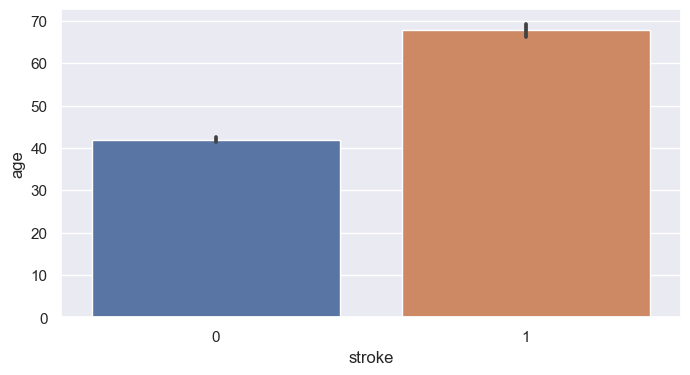

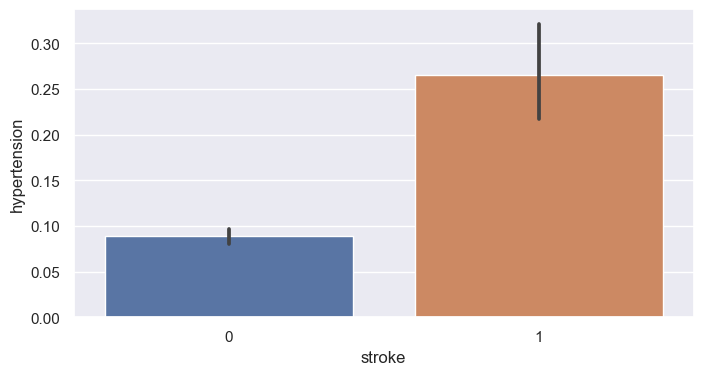

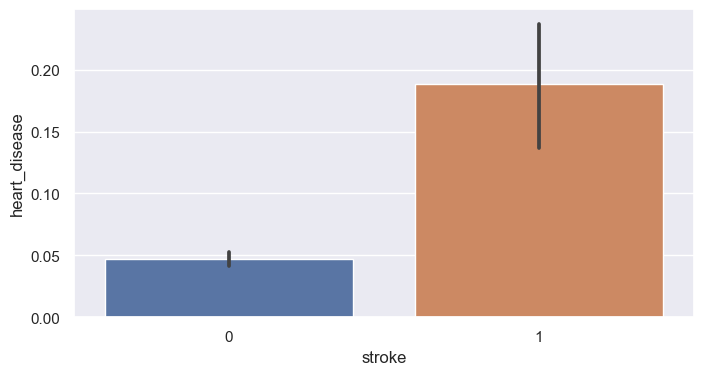

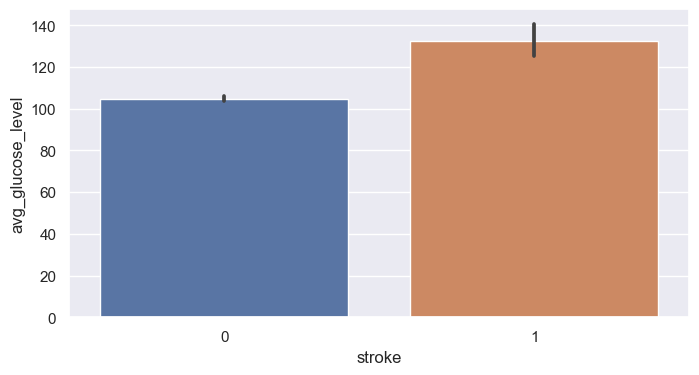

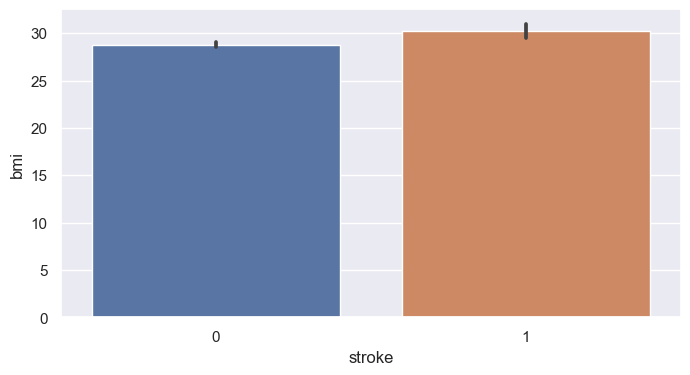

In [296]:
for col in num_feat:
    plt.figure(figsize=(8,4))
    sns.barplot(data=df,x='stroke',y=col)

    plt.show() #visual distribution of stroke across numerical features

In [297]:
df.isna().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
agegroup             0
dtype: int64

<AxesSubplot:ylabel='avg_glucose_level'>

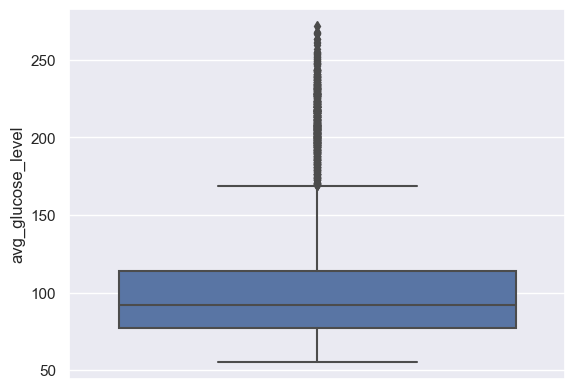

In [298]:
sns.boxplot(y = df['avg_glucose_level'])#outlierss

### EDA

##### Is the Target Variable imbalanced?

In [299]:
df['stroke'].value_counts(normalize=True)

0    0.951262
1    0.048738
Name: stroke, dtype: float64

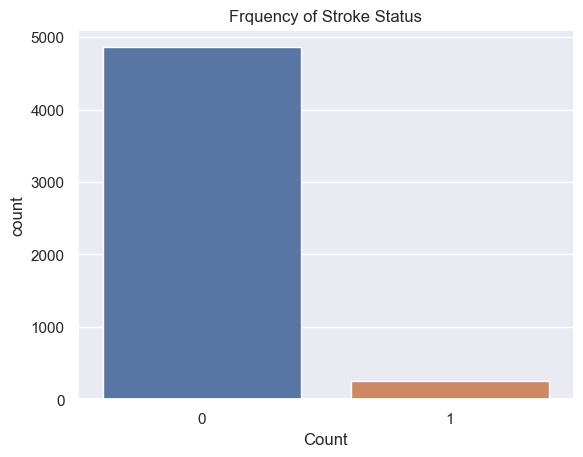

In [300]:
sns.countplot(x=df['stroke'])
plt.xlabel('Stroke')
plt.xlabel('Count')
plt.title('Frquency of Stroke Status');

y is greatly imbalanced

In [301]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,9046,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,51676,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,31112,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,60182,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,1665,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age


##### Distribution of target variable and age

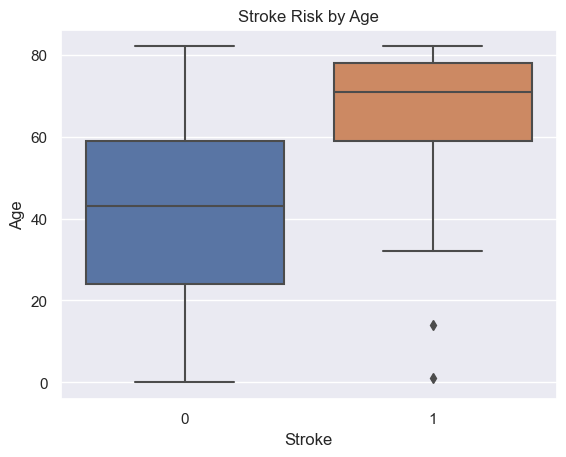

In [302]:
sns.boxplot(x='stroke',y ='age',data = df)
plt.xlabel('Stroke')
plt.ylabel('Age')
plt.title('Stroke Risk by Age');

In [303]:
df.groupby('stroke')['age'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,41.962963,22.314896,0.0,24.0,43.0,59.0,82.0
1,249.0,67.726908,12.734166,1.0,59.0,71.0,78.0,82.0


Stroke is predominant in ages between 35-80 with outliers

In [304]:
df[(df['stroke'] == 1) & (df['age']< 35)]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
162,69768,Female,1,0,0,No,children,Urban,70.37,19.9,Unknown,1,Teens
182,39912,Female,32,0,0,Yes,Private,Rural,76.13,29.9,smokes,1,Young adult
245,49669,Female,14,0,0,No,children,Rural,57.93,30.9,Unknown,1,Teens


Stroke patients are significantly older than non-stroke patients.

The presence of stroke cases at ages 1 and 14 likely represents:
- Rare pediatric stroke cases
 


Aggregate by worktype

In [305]:
work_pivot = pd.pivot_table(df,index='work_type',values='stroke',aggfunc=np.mean)
work_pivot.sort_values(by='stroke')

,stroke
work_type,
Never_worked,0.000000
children,0.002911
Govt_job,0.050228
Private,0.050958
Self-employed,0.079365


In [306]:
work_pivot.values

array([[0.05022831],
       [0.        ],
       [0.05095759],
       [0.07936508],
       [0.00291121]])

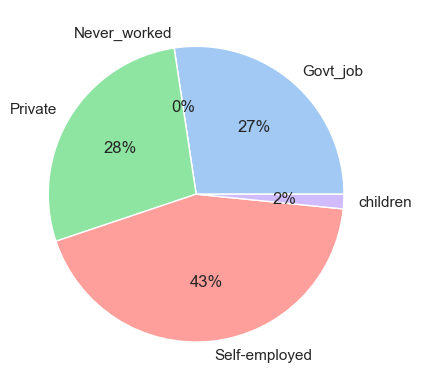

In [307]:
plt.figure()
plt.pie(work_pivot.iloc[:,0],
        labels=work_pivot.index,
        colors=sns.color_palette('pastel'),
        autopct='%.0f%%');


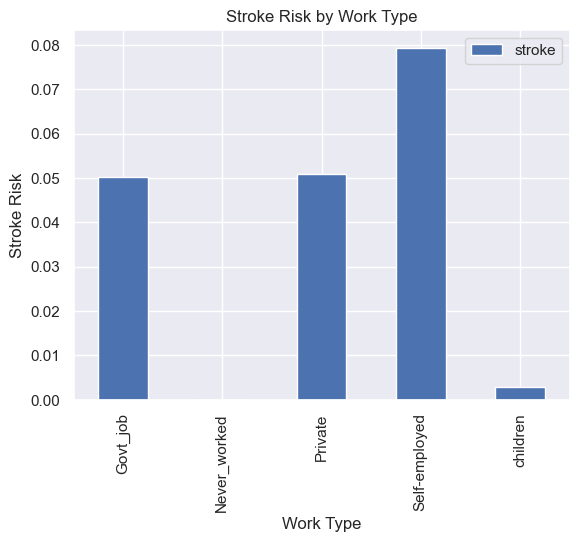

In [308]:
work_pivot.plot(kind='bar')
plt.xlabel('Work Type')
plt.ylabel('Stroke Risk')
plt.title('Stroke Risk by Work Type');

Self-employed individuals show slightly higher stroke incidence.

In [309]:
df.select_dtypes('object').nunique() #checks for high/low cardinalty categorical feature

gender            2
ever_married      2
work_type         5
Residence_type    2
smoking_status    4
agegroup          6
dtype: int64

In [310]:
df.select_dtypes('number').nunique()

id                   5109
age                    83
hypertension            2
heart_disease           2
avg_glucose_level    3978
bmi                   419
stroke                  2
dtype: int64

In [311]:
#drop high cardinal features
df.drop(columns='id',inplace=True)

In [312]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,80,1,0,Yes,Private,Urban,83.75,28.0,never smoked,0,Old age
5105,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Old age
5106,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Young adult
5107,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Early midlife


##### Does stroke differ by gender?

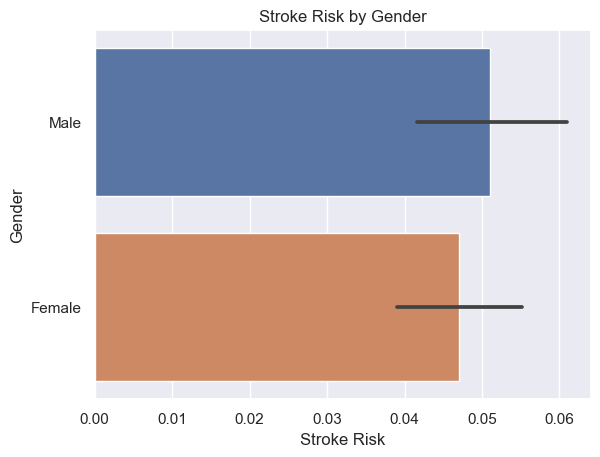

In [313]:
sns.barplot(data=df, x="stroke", y="gender",orient='h')
plt.ylabel('Gender')
plt.xlabel('Stroke Risk')
plt.title('Stroke Risk by Gender');

In [314]:
gender = df.groupby(df['gender'])['stroke'].mean()
data_gender = pd.DataFrame({'labels':gender.index,
                          'values':gender.values})

In [315]:
fig= px.pie(data_gender,values='values',names='labels',title='stroke by gender',color =['Female','Male'])
fig.show()

Stroke incidence is slightly higher in males , but the difference is marginal.

In [316]:
df.to_csv('stroke_data.csv')

##### At what age does stroke frequency increase sharply?

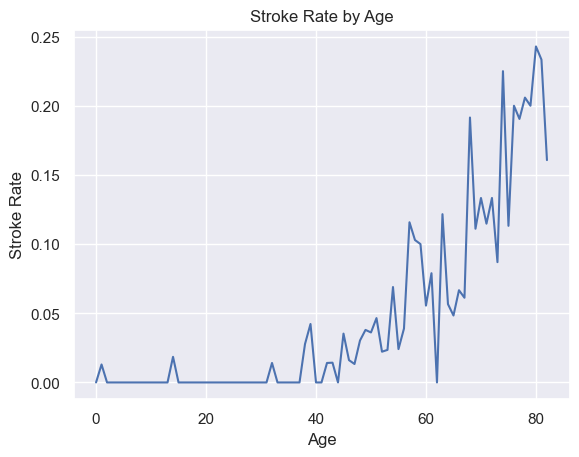

In [317]:
stroke_rate = df.groupby('age')['stroke'].mean()

# Plot
plt.figure()
plt.plot(stroke_rate.index, stroke_rate.values)
plt.xlabel('Age')
plt.ylabel('Stroke Rate')
plt.title('Stroke Rate by Age');

In [318]:
age = df.groupby(df['agegroup'])['stroke'].mean()
data_age=  pd.DataFrame({'labels':age.index,
                          'values':age.values})

In [319]:
fig= px.pie(data_age,values='values',names='labels',title='stroke by agegroup')
fig.show()

#### Stroke Rate by Age

The stroke rate increases progressively with age, with a noticeable acceleration after approximately **55–60 years**.Stroke is generally predominant in old age as expected

##### Key Observations:

- Stroke incidence is near zero below age 40.
- A gradual increase begins around 45–50.
- A sharp rise occurs after 60.
- The highest stroke rates are observed in individuals aged 70+.
- Variability at very young ages (e.g., 1–14 years) likely reflects rare cases.

##### Interpretation:

The curve shows a clear non-linear upward trend, indicating that stroke risk accelerates in later adulthood rather than increasing uniformly.


##### What is the BMI distribution ?

Is BMI higher in stroke patients?

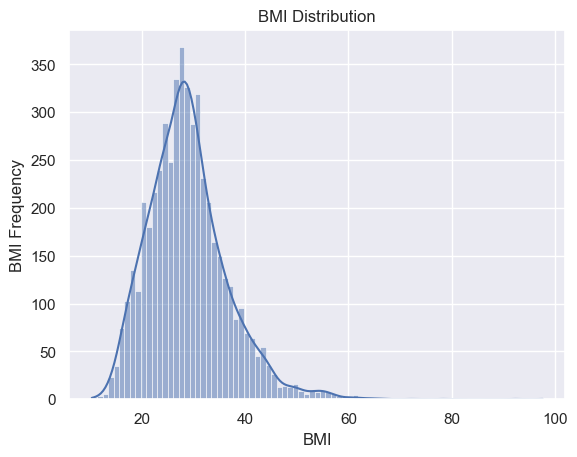

In [320]:
import seaborn as sns
sns.histplot(df['bmi'],kde=True)
plt.xlabel('BMI')
plt.ylabel('BMI Frequency')
plt.title('BMI Distribution');


The BMI distribution is right-skewed.

### Key Observations:

- Most individuals cluster between BMI 20 and 35.
- The peak density lies around 27–30.
- A long right tail extends beyond BMI 40.
- Extreme values exist above 50 but are rare.

### Interpretation:

The right skew indicates presence of higher-BMI individuals, which might be due to abnomal health issues.  




In [321]:
df.groupby('stroke')['bmi'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,28.800556,7.799142,10.3,23.5,28.00,32.8,97.6
1,249.0,30.199398,5.873662,16.9,27.0,29.55,32.5,56.6


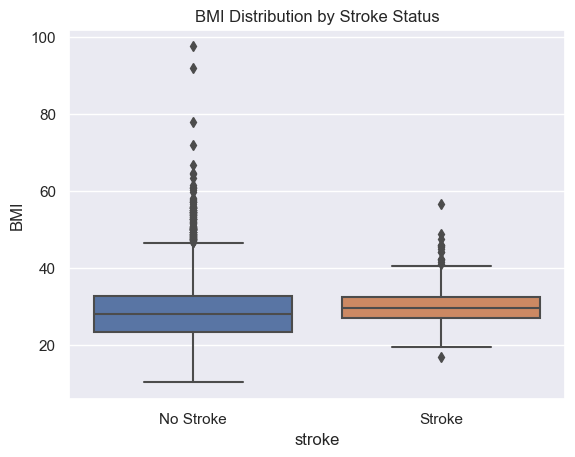

In [322]:
sns.boxplot(x='stroke',y ='bmi',data = df)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('BMI')
plt.title('BMI Distribution by Stroke Status')
plt.show()

Stroke patients show slightly higher BMI values.

However, the difference is modest, and the distributions overlap substantially.

When combining findings:

- Stroke risk rises sharply with age.
- BMI shows modest elevation in stroke patients.
- The impact of BMI likely interacts with age and cardiovascular conditions.

This suggests stroke risk is primarily age-driven, with metabolic and cardiovascular factors acting as amplifiers.

In [323]:
df.groupby('stroke')['avg_glucose_level'].describe()

,count,mean,std,min,25%,50%,75%,max
stroke,,,,,,,,
0,4860.0,104.787584,43.847095,55.12,77.12,91.465,112.80,267.76
1,249.0,132.544739,61.921056,56.11,79.79,105.220,196.71,271.74


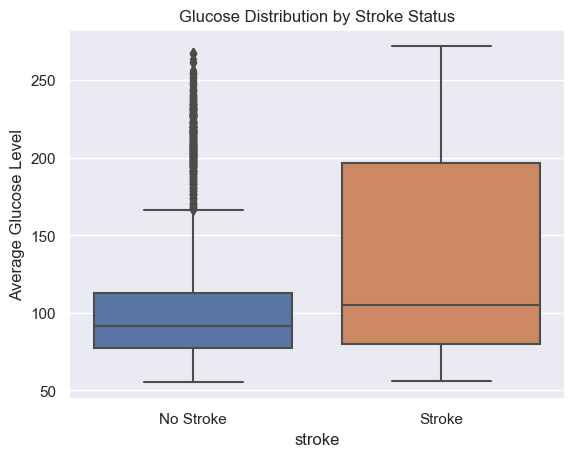

In [324]:
sns.boxplot(x='stroke',y ='avg_glucose_level',data = df)
plt.xticks([0, 1], ['No Stroke', 'Stroke'])
plt.ylabel('Average Glucose Level')
plt.title('Glucose Distribution by Stroke Status')
plt.show()

Stroke patients have higher glucose levels, especially at the upper quartile.

The large difference in mean (104.7 vs 132.5) and wide upper IQR suggests:
- Hyperglycemia is strongly associated with stroke.

Average glucose level is a strong predictive feature.


##### Do heart disease patients have higher stroke rates?

In [325]:
df['heart_disease'].value_counts()

0    4833
1     276
Name: heart_disease, dtype: int64

In [326]:
heart = df.groupby(df['heart_disease'])['stroke'].mean()
data_heart =  pd.DataFrame({'labels':heart.index,
                          'values':heart.values})
fig= px.pie(data_heart,values='values',names={0:'No heart disease',1:'heart disease'},title='Stroke incidence by heart condition')
fig.show()
print(heart)

heart_disease
0    0.041796
1    0.170290
Name: stroke, dtype: float64


Individuals with heart disease have over **4× higher stroke incidence**.



##### What is the distribution of smoking status?

In [327]:
df['smoking_status'].value_counts(normalize=True)

never smoked       0.370327
Unknown            0.302212
formerly smoked    0.173028
smokes             0.154433
Name: smoking_status, dtype: float64

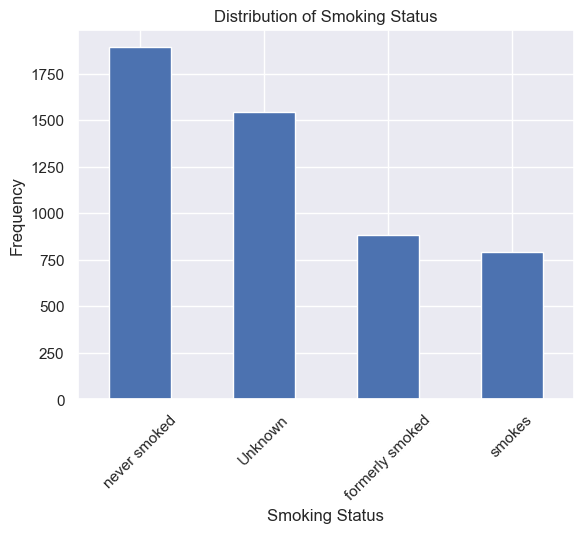

In [328]:
smoking_counts = df['smoking_status'].value_counts()

smoking_counts.plot(kind='bar')
plt.xlabel('Smoking Status')
plt.ylabel('Frequency')
plt.title('Distribution of Smoking Status')
plt.xticks(rotation=45)
plt.show()

In [329]:
stroke_by_smoking = df.groupby('smoking_status')['stroke'].mean().sort_values(ascending=False)
stroke_by_smoking

smoking_status
formerly smoked    0.079186
smokes             0.053232
never smoked       0.047569
Unknown            0.030440
Name: stroke, dtype: float64

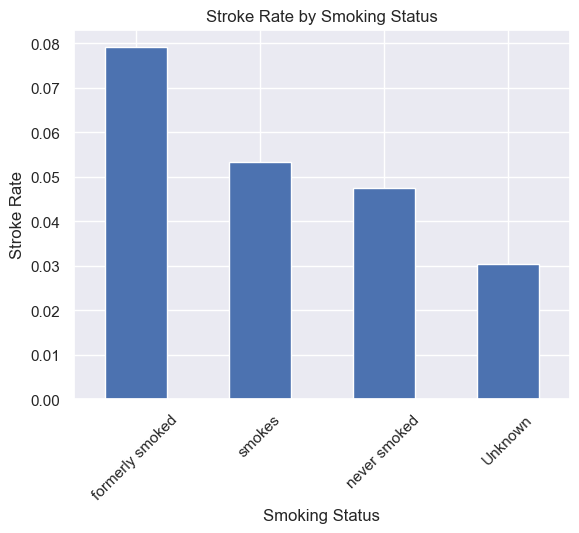

In [330]:
stroke_by_smoking.plot(kind='bar')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate')
plt.title('Stroke Rate by Smoking Status')
plt.xticks(rotation=45);


In [331]:
smoke = df.groupby(df['smoking_status'])['stroke'].mean()
data_smoke =  pd.DataFrame({'labels':smoke.index,
                          'values':smoke.values})
fig= px.pie(data_smoke,values='values',names='labels',title='Stroke incidence by smoking status')
fig.show()
print(smoke.sort_values())

smoking_status
Unknown            0.030440
never smoked       0.047569
smokes             0.053232
formerly smoked    0.079186
Name: stroke, dtype: float64


Former smokers exhibit the highest stroke incidence.
This may likely be due to old age(former smokers tend to be older).

Current smokers show moderately elevated risk compared to never smokers.
 
Smoking is associated with increased stroke risk.

In [332]:
married = df.groupby(df['ever_married'])['stroke'].mean()
data_marriage =  pd.DataFrame({'labels':married.index,
                          'values':married.values})
fig= px.pie(data_marriage,values='values',names='labels',title='stroke by marital status')
fig.show()

Approximately 80% of stroke patients are married 

In [333]:
df['hypertension'].value_counts()

0    4611
1     498
Name: hypertension, dtype: int64

In [334]:
hypertension = df.groupby(df['hypertension'])['stroke'].mean()
data_hypertension =  pd.DataFrame({'labels':hypertension.index,
                          'values':hypertension.values})
fig= px.pie(data_hypertension,values='values',names='labels',title='Distribution of stroke based on hypertension status')
fig.show()

Hypertensive Patients are more likely to have stroke. This is a very strong indicator of stroke

##### Which numerical features are strongly correlated?

Is there multicollinearity?

In [335]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.to_list()
num_cols

['hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

In [336]:
corr_matrix = df[num_cols].corr()
corr_matrix

,hypertension,heart_disease,avg_glucose_level,bmi,stroke
hypertension,1.000000,0.108292,0.174540,0.161863,0.127891
heart_disease,0.108292,1.000000,0.161907,0.040424,0.134905
avg_glucose_level,0.174540,0.161907,1.000000,0.170499,0.131991
bmi,0.161863,0.040424,0.170499,1.000000,0.039010
stroke,0.127891,0.134905,0.131991,0.039010,1.000000


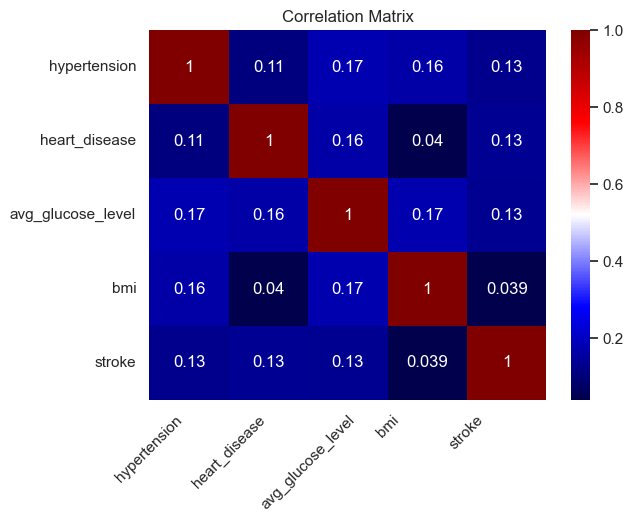

In [337]:
sns.heatmap(corr_matrix,annot=True, cmap='seismic')
plt.xticks(range(len(num_cols)), num_cols, rotation=45)
plt.title('Correlation Matrix');

### Bivarate Analysis

In [338]:
df.groupby('agegroup')['hypertension'].mean().sort_values()

agegroup
Teens            0.001168
Young adult      0.027418
Early midlife    0.098191
Late midlife     0.155585
Early Elderly    0.208251
Old age          0.239382
Name: hypertension, dtype: float64

In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   int32  
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
 11  agegroup           5109 non-null   object 
dtypes: float64(2), int32(1), int64(3), object(6)
memory usage: 459.1+ KB


##### Does hypertension prevalence increase with age group?

At which age group does hypertension rise sharply?

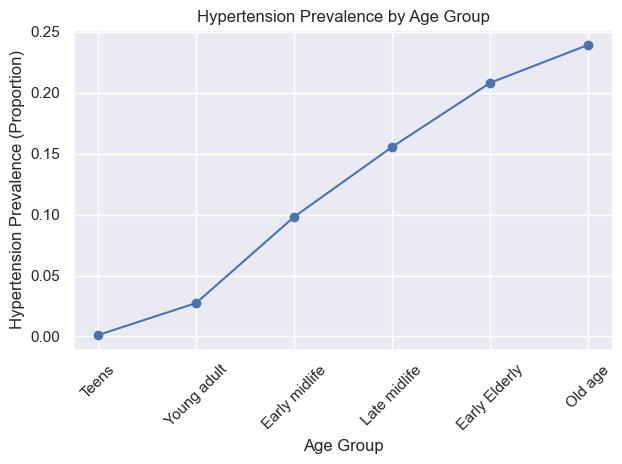

agegroup
Teens            0.001168
Young adult      0.027418
Early midlife    0.098191
Late midlife     0.155585
Early Elderly    0.208251
Old age          0.239382
Name: hypertension, dtype: float64

In [340]:
htn_by_age = df.groupby('agegroup')['hypertension'].mean().sort_values()

plt.figure()
plt.plot(htn_by_age.index.astype(str), htn_by_age.values, marker='o')
plt.xlabel("Age Group")
plt.ylabel("Hypertension Prevalence (Proportion)")
plt.title("Hypertension Prevalence by Age Group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


htn_by_age

A slightly progressive trend across the different age groups

##### What is the stroke rate among hypertensive patients within each age group?

In [341]:
stroke_by_group = (df.groupby(['agegroup', 'hypertension'])['stroke'].mean().unstack())
stroke_by_group.sort_index()
stroke_by_group[0]

agegroup
Early Elderly    0.091811
Early midlife    0.021012
Late midlife     0.070866
Old age          0.182741
Teens            0.002339
Young adult      0.003915
Name: 0, dtype: float64

In [342]:
stroke_by_group = (df.groupby(['agegroup', 'hypertension'])['stroke'].mean().unstack())

stroke_by_group

hypertension,0,1
agegroup,,
Early Elderly,0.091811,0.188679
Early midlife,0.021012,0.061404
Late midlife,0.070866,0.068376
Old age,0.182741,0.241935
Teens,0.002339,0.000000
Young adult,0.003915,0.027778


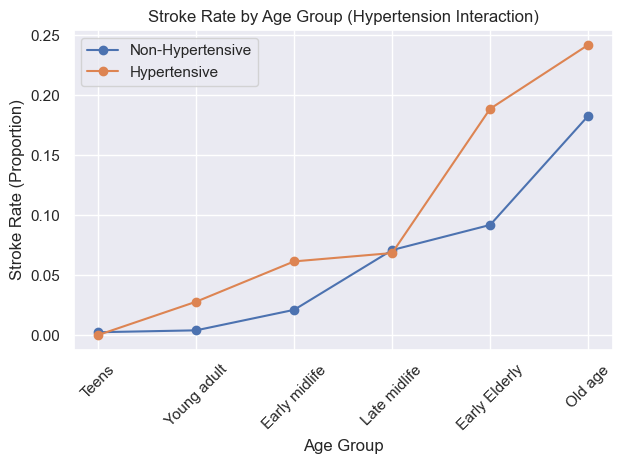

In [343]:
age_order = ["Teens", "Young adult", "Early midlife", "Late midlife", "Early Elderly", "Old age"]
# Convert to categorical with order
df['agegroup_ordered'] = pd.Categorical(df['agegroup'], categories=age_order, ordered=True)
stroke_by_group = (df.groupby(['agegroup_ordered', 'hypertension'])['stroke'].mean().unstack())

# Plot both lines on a single graph
plt.figure()

plt.plot(stroke_by_group.index.astype(str),
         stroke_by_group[0],
         marker='o',
         label='Non-Hypertensive')

plt.plot(stroke_by_group.index.astype(str),
         stroke_by_group[1],
         marker='o',
         label='Hypertensive')

plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (Proportion)")
plt.title("Stroke Rate by Age Group (Hypertension Interaction)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [344]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   gender             5109 non-null   object  
 1   age                5109 non-null   int32   
 2   hypertension       5109 non-null   int64   
 3   heart_disease      5109 non-null   int64   
 4   ever_married       5109 non-null   object  
 5   work_type          5109 non-null   object  
 6   Residence_type     5109 non-null   object  
 7   avg_glucose_level  5109 non-null   float64 
 8   bmi                5109 non-null   float64 
 9   smoking_status     5109 non-null   object  
 10  stroke             5109 non-null   int64   
 11  agegroup           5109 non-null   object  
 12  agegroup_ordered   5109 non-null   category
dtypes: category(1), float64(2), int32(1), int64(3), object(6)
memory usage: 464.3+ KB


In [345]:
df.drop(columns='agegroup_ordered',inplace=True)

In [346]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   int32  
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
 11  agegroup           5109 non-null   object 
dtypes: float64(2), int32(1), int64(3), object(6)
memory usage: 459.1+ KB


##### Is hypertension more common among married individuals?

In [347]:
htn_by_marital = df.groupby('ever_married')['hypertension'].mean()

print(htn_by_marital)

ever_married
No     0.030182
Yes    0.132717
Name: hypertension, dtype: float64


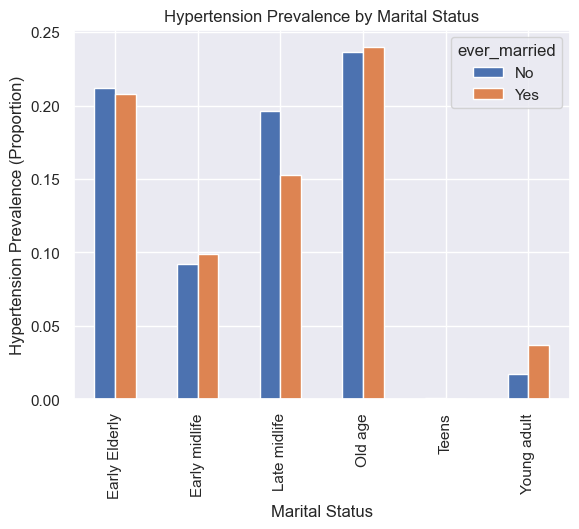

In [348]:
htn_by_age_marital = df.groupby(['agegroup', 'ever_married'])['hypertension'].mean().unstack()


# visualize
htn_by_age_marital.plot(kind='bar')
plt.xlabel("Marital Status")
plt.ylabel("Hypertension Prevalence (Proportion)")
plt.title("Hypertension Prevalence by Marital Status")
plt.show()


Married individuals tend to be older, and hypertension prevalence rises sharply with age (especially after 55). So  hypertension is more common among married people, it’s likely driven by age rather than marriage itself. 

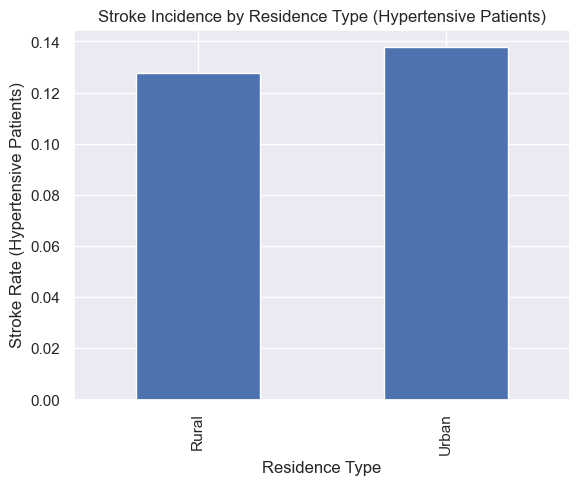

In [349]:
# Filter hypertensive patients
hypertensive_df = df[df['hypertension'] == 1]
stroke_by_residence_htn = hypertensive_df.groupby('Residence_type')['stroke'].mean()

#visualize
stroke_by_residence_htn.plot(kind='bar')
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (Hypertensive Patients)")
plt.title("Stroke Incidence by Residence Type (Hypertensive Patients)")
plt.show()


Is there an interaction: Residence, Hypertension and Stroke?

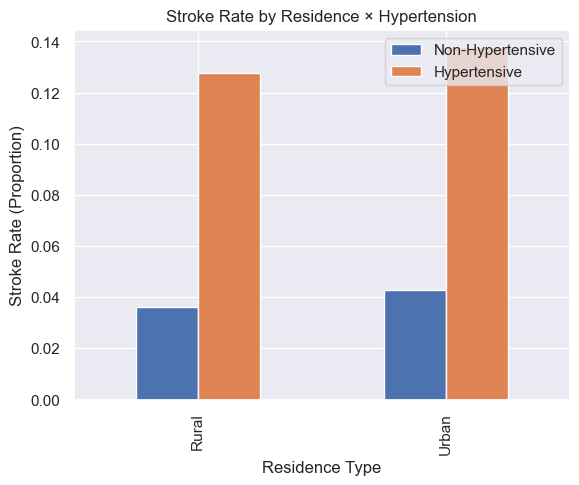

In [350]:
stroke_res_htn = df.groupby(['Residence_type','hypertension'])['stroke'].mean().unstack()


stroke_res_htn.plot(kind='bar')
plt.xlabel("Residence Type")
plt.ylabel("Stroke Rate (Proportion)")
plt.title("Stroke Rate by Residence × Hypertension")
plt.legend(["Non-Hypertensive","Hypertensive"])
plt.show()


Hypertensive patients in Urban areas show higher stroke incidence than hypertensive patients in Rural areas, it suggests lifestyle, stress, or healthcare access may amplify the risk.

### Insights

Strongest Predictors (Based on EDA):
1. Age
2. Heart Disease
3. Average Glucose Level
4. Hypertension

Moderate Predictors:
4. BMI
5. Smoking Status

Weak Predictors:
6. Gender
7. Work Type


### Final Conclusion

Stroke incidence in this dataset is primarily driven by:

- Advanced age
- Cardiovascular disease presence
- Elevated glucose levels
- Hypertension

Lifestyle and demographic factors contribute but appear secondary to clinical variables.


In [351]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,Male,67,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,Early Elderly
1,Female,61,0,0,Yes,Self-employed,Rural,202.21,30.4,never smoked,1,Late midlife
2,Male,80,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Old age
3,Female,49,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,Early midlife
4,Female,79,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,Old age
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,Female,80,1,0,Yes,Private,Urban,83.75,28.0,never smoked,0,Old age
5105,Female,81,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0,Old age
5106,Female,35,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0,Young adult
5107,Male,51,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0,Early midlife


## Model Building

In [352]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost
from xgboost import XGBClassifier

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score  


from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score, roc_curve,ConfusionMatrixDisplay


In [353]:
df.shape

(5109, 12)

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   int32  
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
 11  agegroup           5109 non-null   object 
dtypes: float64(2), int32(1), int64(3), object(6)
memory usage: 459.1+ KB


In [355]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   object 
 1   age                5109 non-null   int32  
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   object 
 5   work_type          5109 non-null   object 
 6   Residence_type     5109 non-null   object 
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   object 
 10  stroke             5109 non-null   int64  
 11  agegroup           5109 non-null   object 
dtypes: float64(2), int32(1), int64(3), object(6)
memory usage: 459.1+ KB


### Feature Encoding

In [356]:
le =LabelEncoder()
df['ever_married'] = le.fit_transform(df['ever_married'])
df['ever_married'].unique()

array([1, 0])

In [357]:
df['gender'].value_counts()

Female    2994
Male      2115
Name: gender, dtype: int64

In [358]:
df['gender'] = le.fit_transform(df['gender'])
df['gender'].value_counts()

0    2994
1    2115
Name: gender, dtype: int64

In [359]:
df['smoking_status'].value_counts()

never smoked       1892
Unknown            1544
formerly smoked     884
smokes              789
Name: smoking_status, dtype: int64

In [360]:
df['smoking_status'] = le.fit_transform(df['smoking_status'])
df['smoking_status'].value_counts()

2    1892
0    1544
1     884
3     789
Name: smoking_status, dtype: int64

In [361]:
df['agegroup'].value_counts()

Young adult      1313
Early midlife    1161
Teens             856
Late midlife      752
Old age           518
Early Elderly     509
Name: agegroup, dtype: int64

In [362]:
df['agegroup'] = le.fit_transform(df['agegroup'])
df['agegroup'].value_counts()

5    1313
1    1161
4     856
2     752
3     518
0     509
Name: agegroup, dtype: int64

In [363]:
df['work_type'].value_counts()

Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: work_type, dtype: int64

In [364]:
df['work_type'] = le.fit_transform(df['work_type'])
df['work_type'].value_counts()

2    2924
3     819
4     687
0     657
1      22
Name: work_type, dtype: int64

In [365]:
df['Residence_type'] = le.fit_transform(df['Residence_type'])
df['Residence_type'].value_counts()

1    2596
0    2513
Name: Residence_type, dtype: int64

### Split

In [366]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5109 entries, 0 to 5108
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5109 non-null   int32  
 1   age                5109 non-null   int32  
 2   hypertension       5109 non-null   int64  
 3   heart_disease      5109 non-null   int64  
 4   ever_married       5109 non-null   int32  
 5   work_type          5109 non-null   int32  
 6   Residence_type     5109 non-null   int32  
 7   avg_glucose_level  5109 non-null   float64
 8   bmi                5109 non-null   float64
 9   smoking_status     5109 non-null   int32  
 10  stroke             5109 non-null   int64  
 11  agegroup           5109 non-null   int32  
dtypes: float64(2), int32(7), int64(3)
memory usage: 339.4 KB


In [367]:
X =df.drop('stroke',axis=1)
y = df['stroke']

In [368]:
print(X.shape)
print(y.shape)

(5109, 11)
(5109,)


#### feature Scaling

In [369]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4087, 11)
y_train shape: (4087,)
X_test shape: (1022, 11)
y_test shape: (1022,)


In [370]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.fit_transform(X_test)

In [371]:
X_test

array([[-0.8437374 , -0.67083858,  2.86482237, ...,  0.9885689 ,
         0.55090798,  1.26471102],
       [-0.8437374 , -1.78122506, -0.34906178, ..., -1.24268874,
        -1.28905265,  0.6894842 ],
       [-0.8437374 ,  0.4395479 , -0.34906178, ...,  0.27562268,
         1.47088829, -1.03619625],
       ...,
       [-0.8437374 , -0.27109945, -0.34906178, ...,  2.22962345,
        -1.28905265,  1.26471102],
       [ 1.18520289, -1.11499317, -0.34906178, ..., -0.70137771,
        -1.28905265,  1.26471102],
       [ 1.18520289,  0.12863969, -0.34906178, ..., -0.55614792,
        -0.36907234, -1.03619625]])

### Imbalance Handling

In [372]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy ='minority',random_state=42)

X_sm,y_sm = smote.fit_resample(X,y)

In [373]:
X_train,X_test,y_train,y_test= train_test_split(X_sm,y_sm,test_size=0.2,random_state=42,stratify=y_sm)

In [374]:
y_train.value_counts()

1    3888
0    3888
Name: stroke, dtype: int64

In [375]:
X_train = ss.fit_transform(X_train)

In [376]:
X_test = ss.fit_transform(X_test)

### Model

###### Logistic Regression

In [377]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)

In [378]:
print('Logistic regression trainScore: ',log_reg.score(X_train,y_train))
print('Logistic regression testScore: ',accuracy_score(y_test,y_pred))

Logistic regression trainScore:  0.8078703703703703
Logistic regression testScore:  0.8004115226337448


In [379]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.76      0.79       972
           1       0.78      0.84      0.81       972

    accuracy                           0.80      1944
   macro avg       0.80      0.80      0.80      1944
weighted avg       0.80      0.80      0.80      1944



[[742 230]
 [158 814]]


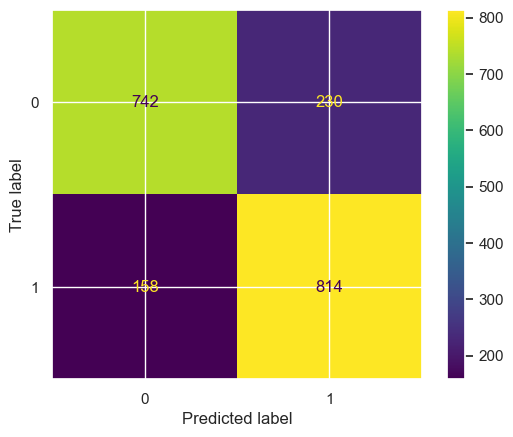

In [380]:
cm = confusion_matrix(y_test,y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(log_reg,X_test,y_test);


In [381]:
lr_prob = log_reg.predict_proba(X_test)[:,1]
lr_auc = roc_auc_score(y_test,lr_prob)
print('AUC score LR',lr_auc)

AUC score LR 0.890107156768108


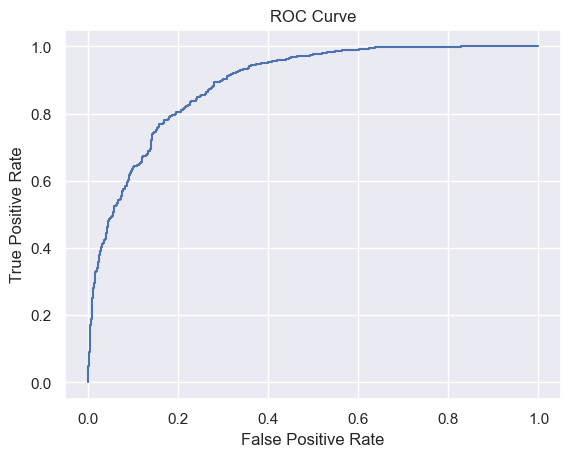

In [429]:
fpr, tpr, threshold = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [382]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,agegroup
0,1,67,0,1,1,2,1,228.69,36.6,1,1,0
1,0,61,0,0,1,3,0,202.21,30.4,2,1,2
2,1,80,0,1,1,2,0,105.92,32.5,2,1,3
3,0,49,0,0,1,2,1,171.23,34.4,3,1,1
4,0,79,1,0,1,3,0,174.12,24.0,2,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...
5104,0,80,1,0,1,2,1,83.75,28.0,2,0,3
5105,0,81,0,0,1,3,1,125.20,40.0,2,0,3
5106,0,35,0,0,1,3,0,82.99,30.6,2,0,5
5107,1,51,0,0,1,2,0,166.29,25.6,1,0,1


In [383]:
df_new =df.drop(columns='stroke')


In [384]:
df_new

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,agegroup
0,1,67,0,1,1,2,1,228.69,36.6,1,0
1,0,61,0,0,1,3,0,202.21,30.4,2,2
2,1,80,0,1,1,2,0,105.92,32.5,2,3
3,0,49,0,0,1,2,1,171.23,34.4,3,1
4,0,79,1,0,1,3,0,174.12,24.0,2,3
...,...,...,...,...,...,...,...,...,...,...,...
5104,0,80,1,0,1,2,1,83.75,28.0,2,3
5105,0,81,0,0,1,3,1,125.20,40.0,2,3
5106,0,35,0,0,1,3,0,82.99,30.6,2,5
5107,1,51,0,0,1,2,0,166.29,25.6,1,1


In [385]:
my_x =[[0,35,0,0,1,3,1,82,27,2,5]]


In [386]:
my_x_df = pd.DataFrame(my_x,columns= df_new.columns)


In [387]:
test_scaled = ss.transform(my_x_df)

In [388]:
log_reg.predict(test_scaled)

array([0], dtype=int64)

### Model2

##### RandomForestClassifier

In [389]:
rf =RandomForestClassifier(n_estimators = 20,random_state=42)
rf.fit(X_train,y_train)
y_pred  = rf.predict(X_test)

In [390]:
print('randomForest trainScore: ',rf.score(X_train,y_train))
print('randomforest testScore: ',accuracy_score(y_test,y_pred))

randomForest trainScore:  0.9992283950617284
randomforest testScore:  0.9398148148148148


In [391]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[912,  60],
       [ 57, 915]], dtype=int64)

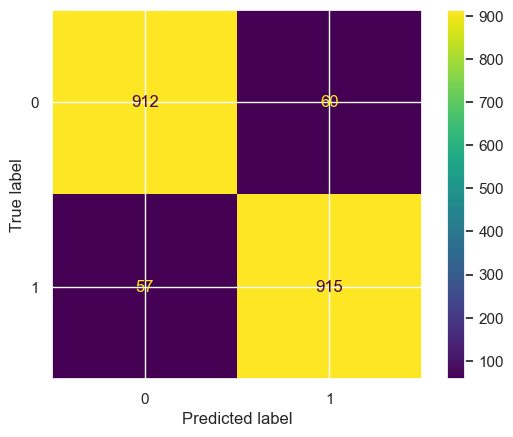

In [392]:
ConfusionMatrixDisplay.from_estimator(rf,X_test,y_test);

In [393]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       972
           1       0.94      0.94      0.94       972

    accuracy                           0.94      1944
   macro avg       0.94      0.94      0.94      1944
weighted avg       0.94      0.94      0.94      1944



In [394]:
rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test,rf_prob)
print('AUC score RF:',rf_auc)

AUC score RF: 0.9825113465088318


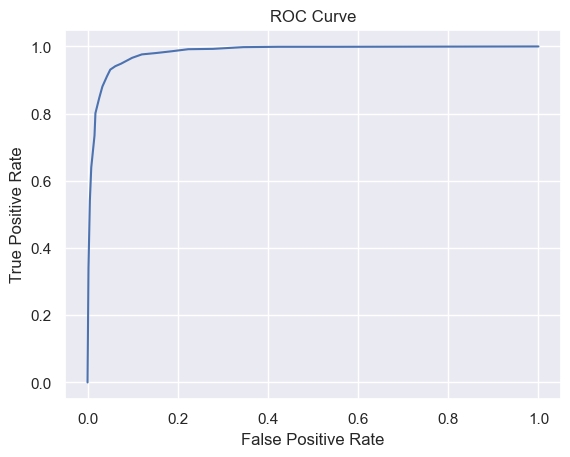

In [431]:
fpr, tpr, threshold = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [395]:
rf.predict(test_scaled)

array([0], dtype=int64)

### Model 3

###### DecisionTreeClassifier

In [396]:
dt = DecisionTreeClassifier(criterion='gini',max_depth = 5,random_state = 42)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)

In [436]:
print('Decisiontree trainScore: ',round(dt.score(X_train,y_train),2))
print('Decisiontree testScore: ',round(accuracy_score(y_test,y_pred),2))

Decisiontree trainScore:  0.83
Decisiontree testScore:  0.89


In [398]:
cm = confusion_matrix(y_test,y_pred)

print(cm)

[[698 274]
 [ 84 888]]


              precision    recall  f1-score   support

           0       0.96      0.81      0.88       972
           1       0.84      0.96      0.90       972

    accuracy                           0.89      1944
   macro avg       0.90      0.89      0.89      1944
weighted avg       0.90      0.89      0.89      1944



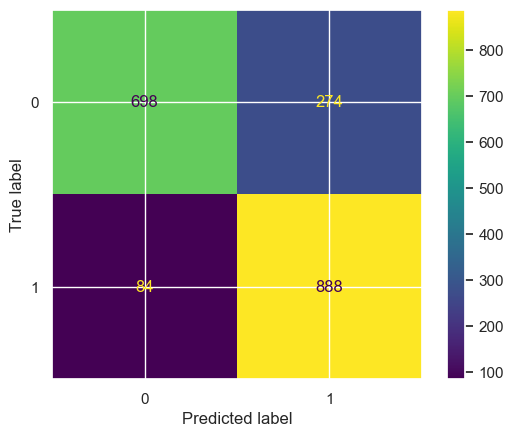

In [434]:
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(dt,X_test,y_test);

In [435]:
dt_prob = dt.predict_proba(X_test)[:,1]
dt_auc = roc_auc_score(y_test,dt_prob)
print('AUC score DT:',round(dt_auc,2))

AUC score DT: 0.89


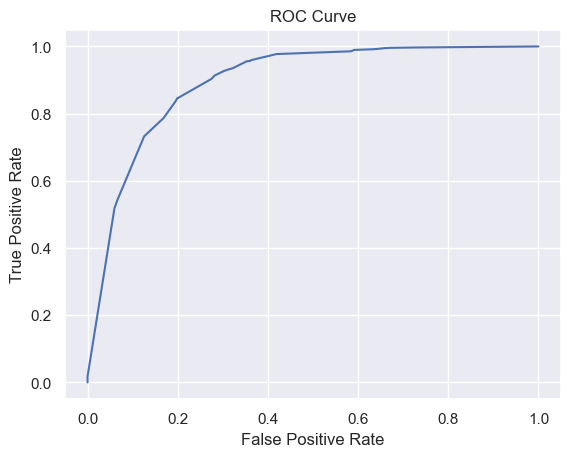

In [433]:
fpr, tpr, threshold = roc_curve(y_test, dt_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Model 4

###### GradientBoostingClassifier

In [401]:
gb = GradientBoostingClassifier(n_estimators= 50,max_depth = 5,random_state = 42)
gb.fit(X_train,y_train)
y_pred = gb.predict(X_test)

In [402]:
print('Gradientboost trainScore: ',gb.score(X_train,y_train))
print('Gradientboost testScore: ',accuracy_score(y_test,y_pred))

Gradientboost trainScore:  0.9157664609053497
Gradientboost testScore:  0.8863168724279835


In [403]:
cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test, y_pred))
print(cm)

              precision    recall  f1-score   support

           0       0.91      0.85      0.88       972
           1       0.86      0.92      0.89       972

    accuracy                           0.89      1944
   macro avg       0.89      0.89      0.89      1944
weighted avg       0.89      0.89      0.89      1944

[[830 142]
 [ 79 893]]


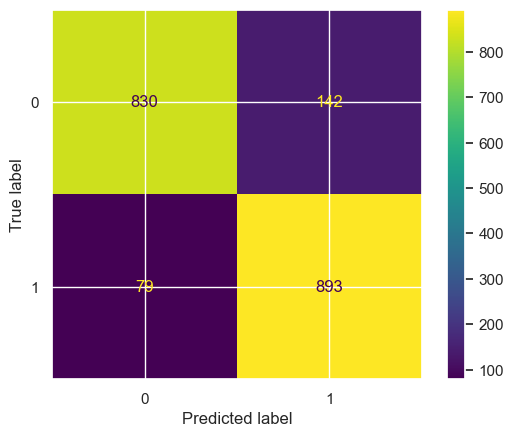

In [437]:
ConfusionMatrixDisplay.from_estimator(gb,X_test,y_test);

In [438]:
gb_prob = gb.predict_proba(X_test)[:,1]
gb_auc = roc_auc_score(y_test,gb_prob)
print('AUC score GB:',round(gb_auc,2))

AUC score GB: 0.95


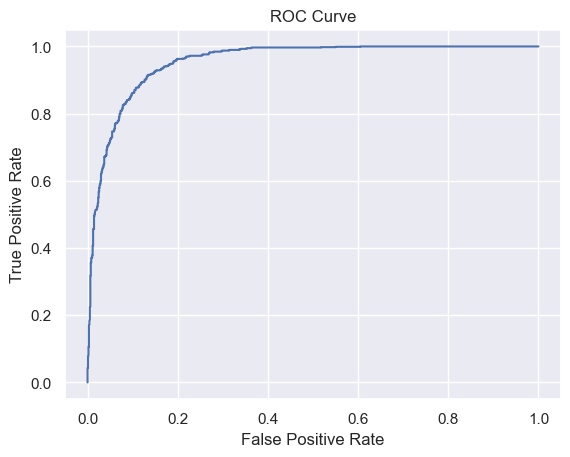

In [439]:
fpr, tpr, threshold = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

### Model 5

###### KNeighborsClassifier

In [405]:
kmn = KNeighborsClassifier(n_neighbors = 3)
kmn.fit(X_train,y_train)
y_pred = kmn.predict(X_test)

In [406]:
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy score ',accuracy)

Accuracy score  0.8955761316872428


In [407]:
k_values = [i for i in range(1,31)]
scores = []

for k in k_values:
    kmn = KNeighborsClassifier(n_neighbors=k)
    score= cross_val_score(kmn, X_train,y_train,cv=5)
    scores.append(np.mean(score))

best_k_index= np.argmax(scores)
best_k = k_values[best_k_index]
best_score = scores[best_k_index]

print('Best k values',best_k)
print('cross validation score with best k',best_score)

Best k values 1
cross validation score with best k 0.8967334000115723


In [408]:
fig = px.line(x = k_values, y =scores,title='KMN scores')
fig.show()

In [409]:
kmn = KNeighborsClassifier(n_neighbors = best_k)
kmn.fit(X_train,y_train)
y_pred = kmn.predict(X_test)

In [410]:
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy score ',accuracy)

Accuracy score  0.9120370370370371


In [411]:
kmn_prob = kmn.predict_proba(X_test)[:,1]
kmn_auc = roc_auc_score(y_test,kmn_prob)
print('AUC score',kmn_auc)

AUC score 0.9120370370370371


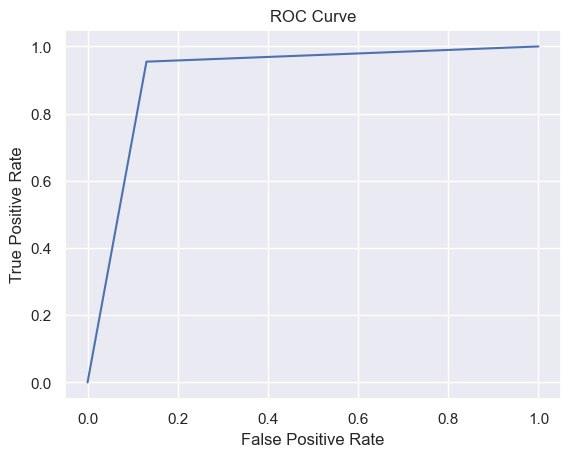

In [441]:
fpr, tpr, threshold = roc_curve(y_test, kmn_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [412]:
cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test, y_pred))
print(cm)

              precision    recall  f1-score   support

           0       0.95      0.87      0.91       972
           1       0.88      0.95      0.92       972

    accuracy                           0.91      1944
   macro avg       0.92      0.91      0.91      1944
weighted avg       0.92      0.91      0.91      1944

[[845 127]
 [ 44 928]]


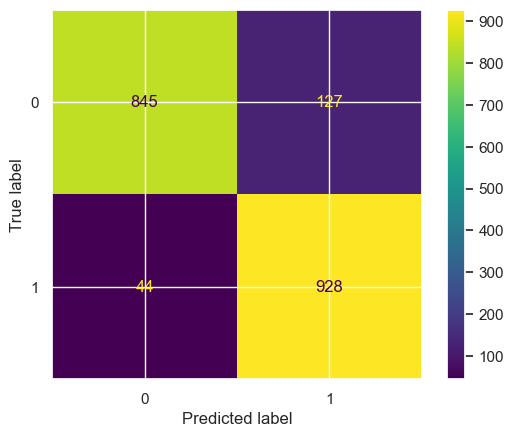

In [440]:
ConfusionMatrixDisplay.from_estimator(kmn,X_test,y_test);

### Model 6

###### XGBClassifier

In [413]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)

In [443]:
accuracy = accuracy_score(y_test,y_pred)
print('Accuracy score XGB: ',round(accuracy,2))

Accuracy score XGB:  0.89


In [415]:
xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test,xgb_prob)
print('AUC score XGB:',xgb_auc)

AUC score XGB: 0.9603539009974766


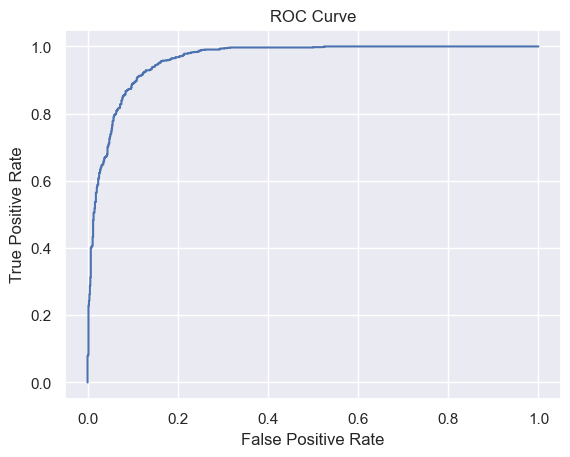

In [444]:
fpr, tpr, threshold = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [416]:
cm = confusion_matrix(y_test,y_pred)
print(classification_report(y_test, y_pred))
print(cm)

              precision    recall  f1-score   support

           0       0.96      0.81      0.88       972
           1       0.84      0.96      0.90       972

    accuracy                           0.89      1944
   macro avg       0.90      0.89      0.89      1944
weighted avg       0.90      0.89      0.89      1944

[[791 181]
 [ 35 937]]


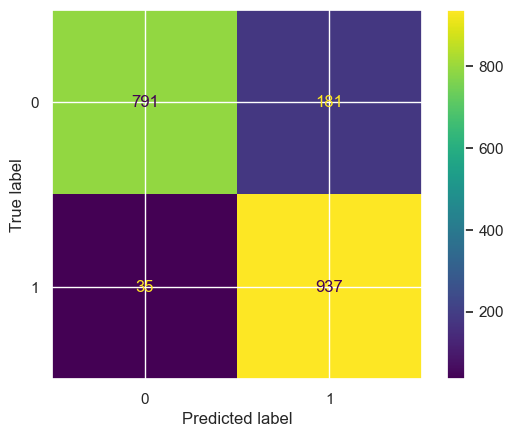

In [445]:
ConfusionMatrixDisplay.from_estimator(xgb,X_test,y_test);

### Hyperparameter Tuning

###### Hypertune the gradient boosting classifier

In [417]:
gb.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'deviance',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 50,
 'n_iter_no_change': None,
 'random_state': 42,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [418]:
params ={'max_depth':range(5,20,5),
         'n_estimators':range(50,100,10),
        }

In [419]:
model_cv = GridSearchCV(gb,param_grid=params,cv = 5,scoring='accuracy',n_jobs=-1,verbose=1)
model_cv.fit(X_train,y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


GridSearchCV(cv=5,
             estimator=GradientBoostingClassifier(max_depth=5, n_estimators=50,
                                                  random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': range(5, 20, 5),
                         'n_estimators': range(50, 100, 10)},
             scoring='accuracy', verbose=1)

In [447]:
model_cv.best_params_

{'max_depth': 10, 'n_estimators': 90}

In [448]:
best_model = model_cv.best_estimator_

In [449]:
print(classification_report(y_test,best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       972
           1       0.93      0.95      0.94       972

    accuracy                           0.94      1944
   macro avg       0.94      0.94      0.94      1944
weighted avg       0.94      0.94      0.94      1944



In [453]:
cm = confusion_matrix(y_test,best_model.predict(X_test))
cm

array([[900,  72],
       [ 50, 922]], dtype=int64)

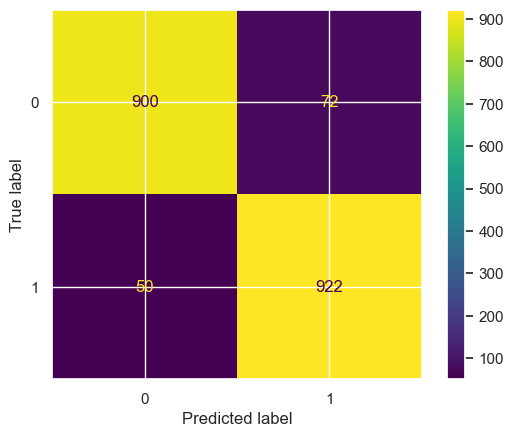

In [454]:
ConfusionMatrixDisplay.from_estimator(model_cv,X_test,y_test);

In [455]:
cv_prob = model_cv.predict_proba(X_test)[:,1]
cv_auc = roc_auc_score(y_test,cv_prob)
print('AUC score',cv_auc)

AUC score 0.9827061000186287


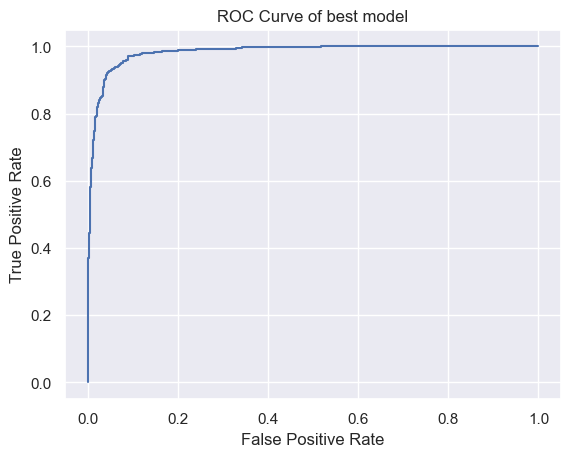

In [456]:
fpr, tpr, threshold = roc_curve(y_test, cv_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of best model")
plt.show()

### Communicate

In [457]:
importances = best_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': importances})

print(importance_df)

              Feature  Importance
0              gender    0.022391
1                 age    0.453459
2        hypertension    0.012964
3       heart_disease    0.013955
4        ever_married    0.020459
5           work_type    0.052109
6      Residence_type    0.025185
7   avg_glucose_level    0.191011
8                 bmi    0.128321
9      smoking_status    0.037732
10           agegroup    0.042413


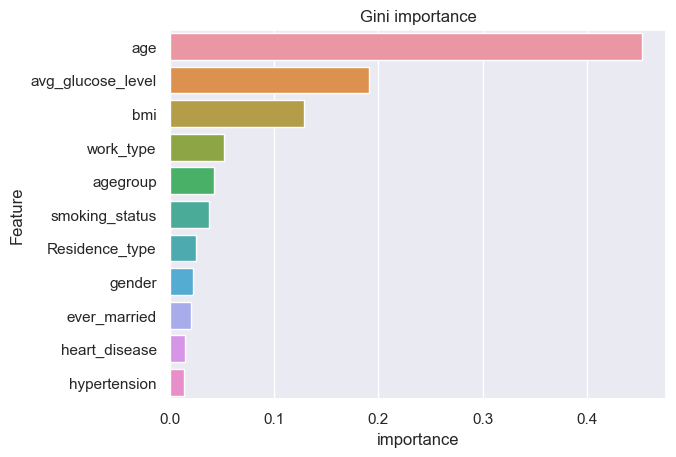

In [458]:
sns.barplot(data=importance_df.sort_values(by='Importance',ascending=False),x='Importance', y='Feature', orient='h')
plt.xlabel('importance')
plt.ylabel('Feature')
plt.title('Gini importance');

In [459]:
import pickle
with open('stroke_model.pkl','wb') as files:
    pickle.dump((best_model,ss),files)

###  Final Insights, Model Evaluation & Project Conclusions

### Project Summary

This project explored clinical and demographic risk factors associated with stroke and developed predictive models to support early medical risk identification. Through data cleaning, exploratory analysis, feature engineering, and machine learning, we translated raw healthcare data into actionable intelligence for preventive care.

The workflow followed a standard data science lifecycle:

1. Data preprocessing and quality checks
2. Exploratory data analysis (EDA)
3. Feature preparation and encoding
4. Model development and evaluation
5. Interpretation and practical implications


###  Key Insights

### 1. Age is the Dominant Risk Factor

Stroke prevalence increases sharply in older age groups, with risk accelerating after midlife. This suggests prevention strategies should begin *before* elderly stages.

### 2. Hypertension as a Major Clinical Driver

Hypertensive individuals show significantly higher stroke incidence, reinforcing blood pressure control as a cornerstone of prevention. Although hypertension is clinically recognized as a major stroke risk factor, its feature importance appears modest in our predictive model. This is likely due to shared variance with age and other cardiovascular indicators, class imbalance, and the binary nature of the variable. Feature importance reflects model-specific predictive contribution rather than real-world causality. 

### 3. BMI as a Contributing Factor

BMI shows a mild positive relationship with stroke risk. It amplifies risk when combined with hypertension, diabetes, and age.

### 4. Socio-Lifestyle Signals

Occupation type and lifestyle patterns suggest access-to-care and stress exposure may influence outcomes.


### Model Performance Review

Multiple classification models were developed to predict stroke risk.

###  Strengths of the Modeling Approach

* Proper preprocessing and encoding pipeline
* Logical feature selection
* Use of train-test split for generalization
* Visual evaluation of patterns before modeling


### Model Limitations and correction

### 1. Class Imbalance Handling

 Stroke datasets are typically highly imbalanced.
And the **risk** is that models may predict the majority class too often.

**Corrections**

* We applied resampling techniques:

  * SMOTE (oversampling minority class)
  
* Evaluate using:

  * Recall
  * F1-score
  * ROC-AUC
    *(We didn't use accuracy alone)*


### 2. ML Workflow

Correct pipeline order:

```
Data preprocessing- EDA- Encoding - Train/Test Split -Scaling -Resampling -Modeling-Evaluation-Communication
```

This is because **Scaling** before splitting may cause data leakage.


### Practical Impact: Early Intervention Framework

This predictive system supports:

### Preventive Healthcare

* Early screening for high-risk individuals
* Targeted hypertension control programs
* Lifestyle modification plans

### Clinical Decision Support

* Automated risk triage
* Prioritized specialist referrals
* Resource allocation planning

### Public Health Strategy

* Age-focused prevention campaigns
* Community screening initiatives
* Data-driven policy planning


### Ethical Considerations

* Ensure fairness across demographic groups
* Avoid bias from underrepresented populations
* Protect patient privacy and data security
* Communicate risk responsibly 

### Future Improvements

* External dataset validation
* Real-time deployment via clinical dashboards


### Final Conclusion

This project demonstrates how data science can transform healthcare data into preventive intelligence. By combining statistical rigor, machine learning, and ethical responsibility, predictive modeling becomes a powerful tool for early intervention and improved patient outcomes.

The results highlight a key principle in medical AI:

The goal is not just prediction  but prevention, prioritization, and better care delivery.
